# Plotting for Project 2

In [94]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
np.random.seed(0)

x0_map = {
    "Simple1": np.array([[-2,2], [1, -2], [1.5, 1]]),
    "Simple2": np.array([[2,2], [-1, -1], [3, 3]]),
    "Simple3": np.array([[1,1,1], [-1, -3, -1], [2, 2, 1]]),
}
x_best_map = {
    "Simple1": np.array([2/3, 1/np.sqrt(3)]),
    "Simple2": np.array([1,1]),
    "Simple3": np.array([-1/np.sqrt(6), np.sqrt(2/3), -1/np.sqrt(6)]),
}

## Quadratic penalty L-BFGS

In [96]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}
g_pen_hists = {}
g_hists = {}
pen_g_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        x_history, f_pen_history, f_history, pen_f_history, g_pen_history, g_history, pen_g_history = quadratic_penalty_l_bfgs(p.f, p.g, p.c, x0, 2000, p.count)

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [-2.  2.], x_best: [0.66696411 0.57747905], f(x_best): -0.0002576217282369009, c(x_best): [ 4.46164161e-04 -1.24444316e+00]
Problem: Simple1, x0: [ 1. -2.], x_best: [-2.62012948  2.03865837], f(x_best): 5.726449068356591, c(x_best): [0.53599846 0.58147111]
Problem: Simple1, x0: [1.5 1. ], x_best: [0.66686495 0.57743612], f(x_best): -0.0001717286731966472, c(x_best): [ 2.97420673e-04 -1.24430107e+00]
Problem: Simple2, x0: [2 2], x_best: [0.00137431 0.00334288], f(x_best): 0.9983694943551654, c(x_best): [ 7.74381384e-04 -1.99528281e+00]
Problem: Simple2, x0: [-1 -1], x_best: [0.00137431 0.00334288], f(x_best): 0.9983694943551192, c(x_best): [ 7.74381385e-04 -1.99528281e+00]
Problem: Simple2, x0: [3 3], x_best: [0. 0.], f(x_best): 1.0, c(x_best): [ 0. -2.]
Problem: Simple3, x0: [1 1 1], x_best: [-0.40841279  0.81691112 -0.40841279], f(x_best): -0.0011580856142749951, c(x_best): [0.0009458]
Problem: Simple3, x0: [-1 -3 -1], x_best: [-0.40850341  0.8168205  -0.40850341

### Contour plot with feasible region for Simple1

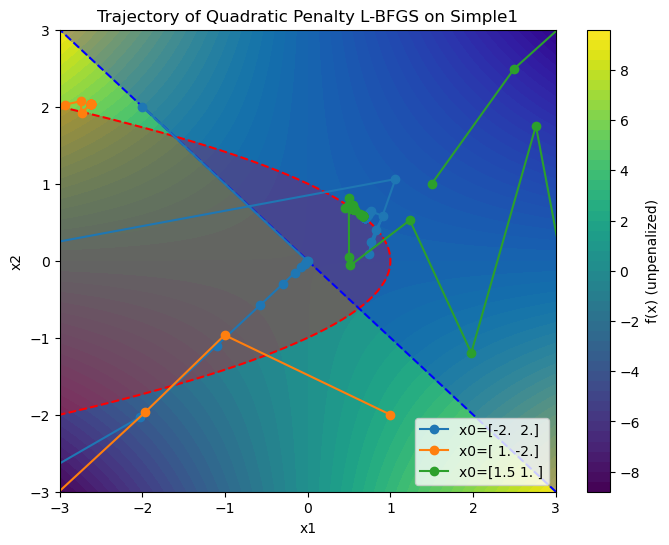

In [97]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()


In [98]:
# 